# Phonetic Name Matching Analysis

**Hamed Dhiaa · Python · pandas · NYSIIS · Matplotlib**

How much does phonetic matching expand name-reference coverage beyond exact spelling? This project examines first-name tokens in a supplied New York Times children's picture-book bestseller dataset (2008–2017).

It is a revised DataCamp learning project. It measures **string-matching coverage**, not identity or demographic attributes. No gender, nationality or birthplace is assigned to authors.

Run all cells in order. Keep both CSVs beside the notebook. The name reference aggregates the original supplied frequencies across demographic categories and omits those labels.

## 1. Load, normalize and match

Normalize case and Latin diacritics, keep alphabetic characters, and take the first whitespace-delimited author token. Treat single-letter initials and empty tokens separately. Use Jellyfish's NYSIIS implementation for both datasets so code variants cannot be mixed.

Matching precedence is: exact normalized spelling, phonetic-only reference match, no reference match, or initial/unparseable token. Frequencies are retained for provenance, but do not weight these coverage counts.

In [1]:
from pathlib import Path
import re
import unicodedata
import pandas as pd
import matplotlib.pyplot as plt
import jellyfish
from IPython.display import display

required_files = ["author_entries.csv", "name_frequencies.csv"]
missing = [name for name in required_files if not Path(name).is_file()]
if missing:
    raise FileNotFoundError(f"Download or upload these repository files first: {missing}")
entries = pd.read_csv("author_entries.csv")
reference = pd.read_csv("name_frequencies.csv")
if not {"Year", "Author", "Book Title"}.issubset(entries.columns):
    raise ValueError("Author dataset is missing required columns.")
if not {"Name", "Frequency"}.issubset(reference.columns):
    raise ValueError("Name reference is missing required columns.")
entries["Year"] = pd.to_numeric(entries["Year"], errors="raise")
if entries["Year"].isna().any():
    raise ValueError("Every entry needs a year.")
reference["Frequency"] = pd.to_numeric(reference["Frequency"], errors="raise")
if reference["Frequency"].isna().any() or reference["Frequency"].lt(0).any():
    raise ValueError("Reference frequencies must be nonnegative numbers.")

def normalize_name(value):
    if pd.isna(value):
        return ""
    ascii_text = unicodedata.normalize("NFKD", str(value)).encode("ascii", "ignore").decode()
    return re.sub(r"[^A-Z]", "", ascii_text.upper())

def first_token(value):
    if pd.isna(value) or not str(value).strip():
        return ""
    token = str(value).split()[0]
    if re.fullmatch(r"(?:[A-Za-z]\.)+|[A-Za-z]\.?", token):
        return ""
    return normalize_name(token)

def phonetic_key(name):
    return jellyfish.nysiis(name) if len(name) > 1 else ""

reference["normalized_name"] = reference["Name"].map(normalize_name)
reference = reference.loc[reference["normalized_name"].str.len().gt(1)].copy()
reference["phonetic_key"] = reference["normalized_name"].map(phonetic_key)
exact_names = set(reference["normalized_name"])
reference_keys = set(reference["phonetic_key"]) - {""}
entries["first_token"] = entries["Author"].map(first_token)
entries["phonetic_key"] = entries["first_token"].map(phonetic_key)

categories = ["Exact spelling", "Phonetic only", "No reference match", "Initial or unparseable"]
def match_status(name):
    if len(name) <= 1:
        return "Initial or unparseable"
    if name in exact_names:
        return "Exact spelling"
    if phonetic_key(name) in reference_keys:
        return "Phonetic only"
    return "No reference match"
entries["match_status"] = entries["first_token"].map(match_status)
summary = entries["match_status"].value_counts().reindex(categories, fill_value=0).rename("Entries")
display(summary.to_frame())
print(f"{len(entries):,} book-year entries; {entries['Author'].nunique():,} distinct author strings.")
print(f"Years: {int(entries['Year'].min())} to {int(entries['Year'].max())}.")
print(f"{len(exact_names):,} normalized reference names; {len(reference_keys):,} phonetic keys.")


,Entries
match_status,
Exact spelling,589
Phonetic only,4
No reference match,9
Initial or unparseable,1


603 book-year entries; 230 distinct author strings.
Years: 2008 to 2017.
96,174 normalized reference names; 19,937 phonetic keys.


## 2. Collisions and yearly coverage

A shared phonetic key can group different spellings; it does not prove equivalent pronunciation or that two records refer to the same person. Each dataset row is a book-year entry. An author can occur on several rows, so these counts are **not counts of unique authors**. A second summary counts distinct normalized first tokens to make this distinction explicit.

In [2]:
valid_names = entries.loc[entries["first_token"].str.len().gt(1), ["first_token", "phonetic_key"]].drop_duplicates()
collisions = valid_names.groupby("phonetic_key")["first_token"].agg(lambda s: sorted(set(s)))
collisions = collisions.loc[collisions.map(len).gt(1)].to_frame("Spellings")
collisions["Distinct spellings"] = collisions["Spellings"].map(len)
collisions = collisions.sort_values("Distinct spellings", ascending=False)
display(collisions.head(10))
yearly = pd.crosstab(entries["Year"], entries["match_status"]).reindex(columns=categories, fill_value=0).sort_index()
yearly_percent = yearly.div(yearly.sum(axis=1), axis=0).mul(100)
display(yearly)
# Compare unique tokens as well as repeated book-year entries.
unique_token_summary = entries.drop_duplicates("first_token")["match_status"].value_counts().reindex(categories, fill_value=0)
display(unique_token_summary.rename("Distinct normalized first tokens").to_frame())


,Spellings,Distinct spellings
phonetic_key,,
JAN,"[JAMES, JAN, JANE, JEAN, JOAN, JOHN, JON, JONAH]",8
JANY,"[JAMIE, JENNY, JIMMY]",3
TAD,"[TAD, TEDD, TODD]",3
LAR,"[LAURA, LORA, LORI]",3
CATY,"[CATHY, KATHIE]",2
CAT,"[KATE, KEITH]",2
AN,"[AME, ANNA]",2
BRANDAN,"[BRANDON, BRENDAN]",2
ELAS,"[ELISE, ELIZA]",2


match_status,Exact spelling,Phonetic only,No reference match,Initial or unparseable
Year,,,,
2008,23,1,1,0
2009,63,1,3,0
2010,76,0,0,0
2011,73,0,1,0
2012,69,0,0,0
2013,63,0,2,0
2014,55,1,1,0
2015,48,0,0,0
2016,58,0,0,0


,Distinct normalized first tokens
match_status,
Exact spelling,162
Phonetic only,3
No reference match,4
Initial or unparseable,1


## 3. Visual summary

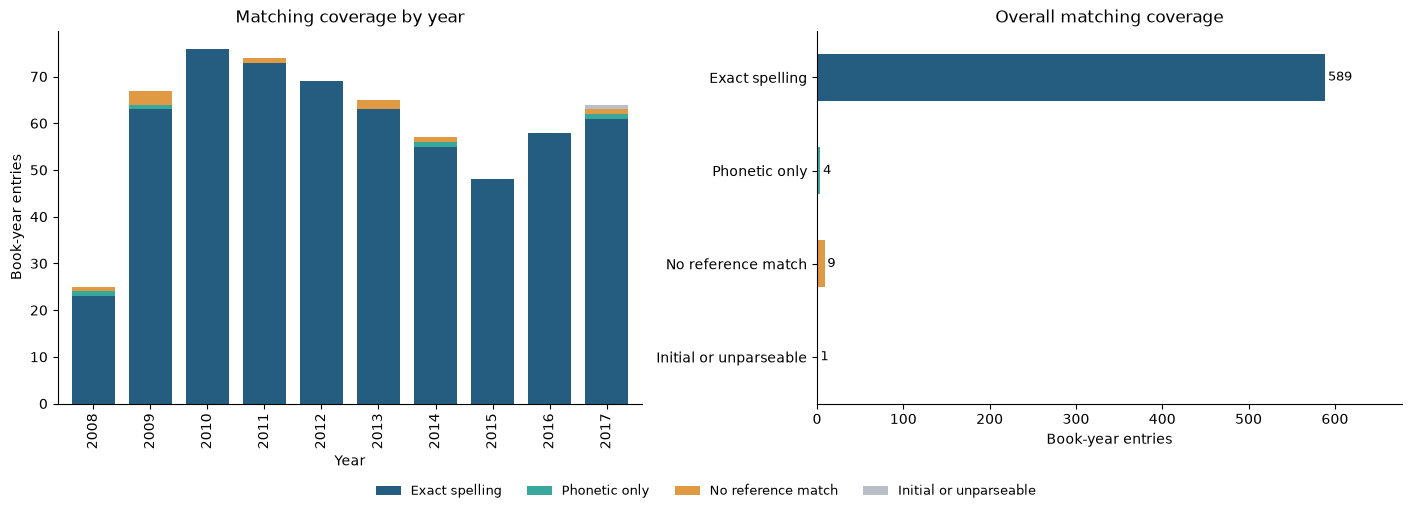

In [3]:
colors = ["#245d80", "#38a89d", "#df9a43", "#b9bec7"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
yearly.plot.bar(stacked=True, ax=axes[0], color=colors, width=0.75)
axes[0].set(title="Matching coverage by year", xlabel="Year", ylabel="Book-year entries")
handles, labels = axes[0].get_legend_handles_labels()
axes[0].get_legend().remove()
fig.legend(handles, labels, loc="outside lower center", ncol=4, frameon=False, fontsize=9)
summary.plot.barh(ax=axes[1], color=colors)
axes[1].set(title="Overall matching coverage", xlabel="Book-year entries", ylabel="")
axes[1].invert_yaxis()
for i, value in enumerate(summary):
    axes[1].text(value + 3, i, str(value), va="center", fontsize=9)
axes[1].set_xlim(0, max(summary.max() * 1.15, 1))
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)
fig.savefig("matching_coverage.png", dpi=160, facecolor="white")
plt.show()


## Interpretation and limitations

In this dataset, 589 of 603 entries match by normalized spelling. Phonetic matching adds 4 candidate matches, leaving 9 unmatched entries and 1 initial-only entry. The added coverage is modest, and matching collisions show why human review remains important.

Phonetic matching is useful for generating candidate string matches, but coverage is not accuracy: this dataset contains no verified matching ground truth. A phonetic-only match is a candidate, not a confirmed match.

- Historical US name-reference coverage is incomplete. An unmatched name says nothing about the author's identity or place of birth.
- NYSIIS and ASCII normalization are not language-neutral. Some distinct spellings collapse together, and non-Latin-only names can become empty.
- First-token extraction does not handle all naming conventions, titles, pseudonyms or multi-author credits. Initials are excluded from phonetic matching.
- Repeated authors and books contribute repeated book-year entries. No author deduplication or popularity weighting is claimed.
- The supplied reference lacks a documented observation period in this archive; results describe this reference file only.

A useful follow-up is a manually reviewed set of spelling pairs to measure precision and recall before using these matches for record linkage.

## Provenance

Adapted from a DataCamp exercise using supplied NYT book-list data and an SSA-derived name-frequency reference. Demographic labels were removed and frequencies aggregated by name. The precomputed demographic lookup and original demographic-inference notebook are not used. Source-data rights remain with their respective owners.